In [ ]:
!ls

In [ ]:
import torch
!pip install torch-geometric

In [ ]:
import pandas as pd

data = pd.read_csv("PHQ-9_Dataset_5th Edition.csv")

print(data.head())
print(data.columns)

In [ ]:
# FIX COLUMN NAMES (VERY IMPORTANT)
data.columns = data.columns.str.strip()

In [ ]:
# STEP 2: Select Features

core_features = ['Sleep Quality', 'Study Pressure', 'Financial Pressure']

phq_features = [
    'Little interest or pleasure in doing things',
    'Feeling down, depressed, or hopeless',
    'Trouble falling or staying asleep, or sleeping too much',
    'Feeling tired or having little energy',
    'Trouble concentrating on things, such as reading the newspaper or watching television'
]

data = data[core_features + phq_features + ['PHQ_Severity']].copy()

In [ ]:
# STEP 3: Convert PHQ Features to Numbers

phq_map = {
    'not at all': 0,
    'several days': 1,
    'more than half the days': 2,
    'nearly every day': 3
}

for col in phq_features:
    data[col] = data[col].astype(str).str.strip().str.lower()
    data[col] = data[col].map(phq_map)

In [ ]:
# STEP 4: Convert Sleep / Study / Financial

mapping = {
    'worst': 0,
    'bad': 1,
    'average': 2,
    'good': 3
}

for col in core_features:
    print(data[col].unique())   # 👈 check values first

    data[col] = data[col].astype(str).str.strip().str.lower()
    data[col] = data[col].map(mapping)
    print(data['Sleep Quality'].unique())
    print(data['Study Pressure'].unique())
    print(data['Financial Pressure'].unique())

In [ ]:
# STEP 5: Convert Target (PHQ Severity)

severity_map = {
    'Minimal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Moderately severe': 3,
    'Severe': 4
}

data['PHQ_Severity'] = data['PHQ_Severity'].map(severity_map)

In [ ]:
# STEP 6: Handle Missing Values

print(data.isna().sum())   # check first

data = data.fillna(0)

In [ ]:
# STEP 7: Create Interaction Features

data['Sleep_Study'] = data['Sleep Quality'] * data['Study Pressure']
data['Study_Financial'] = data['Study Pressure'] * data['Financial Pressure']# STEP 7: Create Interaction Features

In [ ]:
# STEP 8: Define Input and Output

X = data.drop('PHQ_Severity', axis=1)
y = data['PHQ_Severity']

In [ ]:
# STEP 8: Define Input and Output

X = data.drop('PHQ_Severity', axis=1)
y = data['PHQ_Severity']

In [ ]:
# STEP 9: Train Test Split (FIXED)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42   # 🔥 ADD THIS
)

In [ ]:
# STEP 10: Train Model

from sklearn.ensemble import RandomForestClassifier

# STEP 10: Tuned Random Forest 🔥

rf_model = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=10,            # control overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

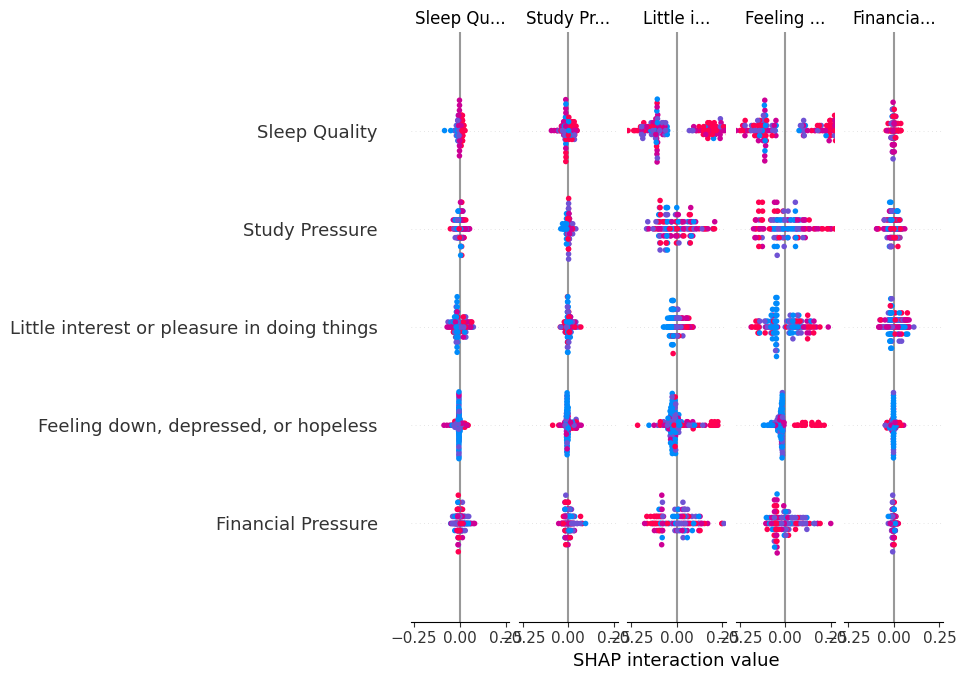

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
# STEP 11: Prediction & Accuracy

from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7591240875912408


In [ ]:
# STEP 12: Convert to Torch (UPDATED)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import torch
X_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y.values, dtype=torch.long)

In [ ]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import NearestNeighbors

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import to_undirected

# ───────────────────────────────────────
# ✅ FIXED PATH (IMPORTANT)
# ───────────────────────────────────────
CSV_PATH = "PHQ-9_Dataset_5th Edition.csv"

# CONFIG
K_NEIGHBORS = 8
NUM_HEADS   = 4
HIDDEN_DIM  = 64
DROPOUT     = 0.3
LR          = 0.001
WEIGHT_DECAY= 1e-4
EPOCHS      = 500
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Running on: {DEVICE}")

# ───────────────────────────────────────
# PREPROCESSING
# ───────────────────────────────────────
def load_and_preprocess(csv_path):
    df = pd.read_csv(csv_path)

    phq_map = {"Not at all": 0, "Several days": 1, "More than half the days": 2, "Nearly every day": 3}
    ext_map = {"Good": 0, "Average": 1, "Bad": 2, "Worst": 3}
    sev_map = {"Minimal": 0, "Mild": 1, "Moderate": 2, "Moderately severe": 3, "Severe": 4}

    exclude = ["Age", "Gender", "PHQ_Total", "PHQ_Severity", "Sleep Quality", "Study Pressure", "Financial Pressure"]
    phq_cols = [c for c in df.columns if c not in exclude]

    for col in phq_cols:
        df[col] = df[col].map(phq_map)

    for col in ["Sleep Quality", "Study Pressure", "Financial Pressure"]:
        df[col] = df[col].map(ext_map)

    df["Gender"] = (df["Gender"] == "Female").astype(int)
    df["PHQ_Severity"] = df["PHQ_Severity"].map(sev_map)

    if "PHQ_Total" not in df.columns:
        df["PHQ_Total"] = df[phq_cols].sum(axis=1)

    df = df.fillna(0)  # ✅ IMPORTANT FIX

    X = df.drop("PHQ_Severity", axis=1).values.astype(np.float32)
    y = df["PHQ_Severity"].values.astype(int)

    return X, y

# ───────────────────────────────────────
# MODEL
# ───────────────────────────────────────
class PHQ9_GAT_Ultra(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, heads, dropout):
        super().__init__()

        self.conv1 = GATv2Conv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.ln1 = nn.LayerNorm(hidden_dim * heads)

        self.conv2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(hidden_dim * heads)

        self.shortcut = nn.Linear(in_dim, hidden_dim * heads)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * heads, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x, edge_index):
        raw = self.shortcut(x)

        x = self.conv1(x, edge_index)
        x = self.ln1(x)
        x = F.elu(x)
        x = x + raw

        identity = x
        x = self.conv2(x, edge_index)
        x = self.ln2(x)
        x = F.elu(x)
        x = x + identity

        return self.classifier(x)

# ───────────────────────────────────────
# MAIN PIPELINE
# ───────────────────────────────────────
def main():
    X, y = load_and_preprocess(CSV_PATH)

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=SEED
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=SEED
    )

    sm = SMOTE(k_neighbors=5, random_state=SEED)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train_res)
    X_val_s   = sc.transform(X_val)
    X_test_s  = sc.transform(X_test)

    X_all = np.vstack([X_train_s, X_val_s, X_test_s])
    y_all = np.concatenate([y_train_res, y_val, y_test])

    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS+1, metric='cosine').fit(X_all)
    _, indices = nbrs.kneighbors(X_all)

    src, dst = [], []
    for i, neigh in enumerate(indices):
        for j in neigh[1:]:
            src.append(i)
            dst.append(j)

    edge_index = to_undirected(torch.tensor([src, dst], dtype=torch.long))

    data = Data(
        x=torch.tensor(X_all, dtype=torch.float32).to(DEVICE),
        edge_index=edge_index.to(DEVICE),
        y=torch.tensor(y_all, dtype=torch.long).to(DEVICE)
    )

    # Masks
    tr_m = torch.zeros(len(y_all), dtype=torch.bool)
    vl_m = torch.zeros(len(y_all), dtype=torch.bool)
    ts_m = torch.zeros(len(y_all), dtype=torch.bool)

    tr_m[:len(y_train_res)] = True
    vl_m[len(y_train_res):len(y_train_res)+len(y_val)] = True
    ts_m[len(y_train_res)+len(y_val):] = True

    model = PHQ9_GAT_Ultra(X_all.shape[1], HIDDEN_DIM, 5, NUM_HEADS, DROPOUT).to(DEVICE)

    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0

    for epoch in range(1, EPOCHS+1):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = criterion(out[tr_m], data.y[tr_m])

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(data.x, data.edge_index)[vl_m].argmax(dim=1)
            val_acc = accuracy_score(data.y[vl_m].cpu(), preds.cpu())

            scheduler.step(val_acc)

            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), "best_model.pt")

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Loss {loss.item():.4f} | Val Acc {val_acc*100:.2f}%")

    # TEST
    model.load_state_dict(torch.load("best_model.pt"))
    model.eval()

    preds = model(data.x, data.edge_index)[ts_m].argmax(dim=1).cpu().numpy()

    print("\n🔥 FINAL TEST ACCURACY:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


if __name__ == "__main__":
    main()

[INFO] Running on: cpu
Epoch 50 | Loss 0.0875 | Val Acc 82.76%
Epoch 100 | Loss 0.0351 | Val Acc 83.91%
Epoch 150 | Loss 0.0380 | Val Acc 83.91%
Epoch 200 | Loss 0.0374 | Val Acc 83.91%
Epoch 250 | Loss 0.0383 | Val Acc 83.91%
Epoch 300 | Loss 0.0349 | Val Acc 83.91%
Epoch 350 | Loss 0.0379 | Val Acc 83.91%
Epoch 400 | Loss 0.0374 | Val Acc 83.91%
Epoch 450 | Loss 0.0385 | Val Acc 83.91%
Epoch 500 | Loss 0.0402 | Val Acc 83.91%

🔥 FINAL TEST ACCURACY: 0.8640776699029126
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        31
           1       0.90      0.79      0.84        24
           2       0.81      0.68      0.74        19
           3       0.80      0.84      0.82        19
           4       0.83      1.00      0.91        10

    accuracy                           0.86       103
   macro avg       0.85      0.86      0.85       103
weighted avg       0.86      0.86      0.86       103



In [ ]:
# STEP 23: Take User Input

print("Enter values (0-3):")
print("0 = Worst, 1 = Bad, 2 = Average, 3 = Good\n")

sleep = int(input("Sleep Quality: "))
study = int(input("Study Pressure: "))
financial = int(input("Financial Pressure: "))

# PHQ inputs (0–3)
little_interest = int(input("Little interest in doing things: "))
feeling_down = int(input("Feeling down: "))
sleep_problem = int(input("Trouble sleeping: "))
tired = int(input("Feeling tired: "))
concentration = int(input("Trouble concentrating: "))

Enter values (0-3):
0 = Worst, 1 = Bad, 2 = Average, 3 = Good



In [ ]:
# =========================
# STEP 24: RUN MODEL ON USER INPUT
# =========================

import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data

# Helper function to load and preprocess data to get feature names and the full dataframe
def load_and_preprocess_full_df(csv_path):
    df = pd.read_csv(csv_path)

    # 🔥 FIX: Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Use mappings consistent with the main GAT pipeline (from Xe75h2Gh-rK3)
    phq_map = {"Not at all": 0, "Several days": 1, "More than half the days": 2, "Nearly every day": 3}
    ext_map = {"Good": 0, "Average": 1, "Bad": 2, "Worst": 3}
    sev_map = {"Minimal": 0, "Mild": 1, "Moderate": 2, "Moderately severe": 3, "Severe": 4}

    exclude_from_phq_cols = ["Age", "Gender", "PHQ_Total", "PHQ_Severity", "Sleep Quality", "Study Pressure", "Financial Pressure"]
    phq_question_cols = [c for c in df.columns if c not in exclude_from_phq_cols]

    for col in phq_question_cols:
        df[col] = df[col].map(phq_map)

    for col in ["Sleep Quality", "Study Pressure", "Financial Pressure"]:
        df[col] = df[col].map(ext_map)

    df["Gender"] = (df["Gender"] == "Female").astype(int) # 0 for Male, 1 for Female
    df["PHQ_Severity"] = df["PHQ_Severity"].map(sev_map) # Map target variable

    if "PHQ_Total" not in df.columns:
        df["PHQ_Total"] = df[phq_question_cols].sum(axis=1)

    df = df.fillna(0) # Handle missing values consistently

    # Get the column names that will be used as input features
    feature_cols = df.drop("PHQ_Severity", axis=1).columns.tolist()
    X = df.drop("PHQ_Severity", axis=1).values.astype(np.float32)
    y = df["PHQ_Severity"].values.astype(int)

    return X, y, feature_cols, df

# Load full data to get scaler and feature names from the trained model's perspective
# CSV_PATH is globally available from Xe75h2Gh-rK3
X_full, y_full, feature_cols, full_df_processed = load_and_preprocess_full_df(CSV_PATH)

# Create and fit scaler on the full preprocessed dataset (X_full)
# This scaler is used for user input, as the original GAT scaler (fit on X_train_res) is not globally accessible.
scaler = StandardScaler()
scaler.fit(X_full)

# Determine IN_DIM (number of input features expected by the model)
IN_DIM = X_full.shape[1]

# Instantiate the model (PHQ9_GAT_Ultra class is global from Xe75h2Gh-rK3)
model = PHQ9_GAT_Ultra(IN_DIM, HIDDEN_DIM, 5, NUM_HEADS, DROPOUT).to(DEVICE)
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

# --- Construct user input array with all 15 features --- (Order matters!)
user_input_dict = {}

# Impute default values for features not prompted to the user
user_input_dict['Age'] = full_df_processed['Age'].mean() # Use mean age from dataset
user_input_dict['Gender'] = full_df_processed['Gender'].mode()[0] # Use mode gender from dataset (0 for Male, 1 for Female)

# User-provided inputs (from owBFd24a6scJ)
user_input_dict['Sleep Quality'] = sleep # 0-3 numerical value
user_input_dict['Study Pressure'] = study # 0-3 numerical value
user_input_dict['Financial Pressure'] = financial # 0-3 numerical value
user_input_dict['Little interest or pleasure in doing things'] = little_interest # 0-3 numerical value
user_input_dict['Feeling down, depressed, or hopeless'] = feeling_down # 0-3 numerical value
user_input_dict['Trouble falling or staying asleep, or sleeping too much'] = sleep_problem # 0-3 numerical value
user_input_dict['Feeling tired or having little energy'] = tired # 0-3 numerical value
user_input_dict['Trouble concentrating on things, such as reading the newspaper or watching television'] = concentration # 0-3 numerical value

# Default values for other PHQ questions not prompted (assuming 'Not at all' = 0)
user_input_dict['Poor appetite or overeating'] = 0
user_input_dict['Feeling bad about yourself—or that you are a failure or have let yourself or your family down'] = 0
user_input_dict['Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual'] = 0
user_input_dict['Thoughts that you would be better off dead or of hurting yourself in some way'] = 0

# Calculate PHQ_Total based on all 9 PHQ question scores (5 user-provided, 4 default)
phq_question_values_for_total = [
    user_input_dict['Little interest or pleasure in doing things'],
    user_input_dict['Feeling down, depressed, or hopeless'],
    user_input_dict['Trouble falling or staying asleep, or sleeping too much'],
    user_input_dict['Feeling tired or having little energy'],
    user_input_dict['Poor appetite or overeating'],
    user_input_dict['Feeling bad about yourself—or that you are a failure or have let yourself or your family down'],
    user_input_dict['Trouble concentrating on things, such as reading the newspaper or watching television'],
    user_input_dict['Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual'],
    user_input_dict['Thoughts that you would be better off dead or of hurting yourself in some way']
]
user_input_dict['PHQ_Total'] = sum(phq_question_values_for_total)

# Ensure the order of features matches the model's training input
user_input_ordered = [user_input_dict[col] for col in feature_cols]
user_input_np = np.array(user_input_ordered).reshape(1, -1).astype(np.float32)

# Scale the user input using the fitted scaler
user_input_scaled = scaler.transform(user_input_np)

user_x = torch.tensor(user_input_scaled, dtype=torch.float32).to(DEVICE)

# For a single user input, we create a graph with a self-loop (as in previous attempt)
user_edge_index = torch.tensor([[0], [0]], dtype=torch.long).to(DEVICE) # Self-loop for single node

# Create a Data object for the user
user_data = Data(x=user_x, edge_index=user_edge_index)

# Make prediction
out = model(user_data.x, user_data.edge_index)

# out will be of shape (1, num_classes), so argmax over dim=1
pred = out.argmax(dim=1).item()

labels = ['Minimal','Mild','Moderate','Moderately Severe','Severe']

print("\n🎯 Predicted Stress Level:", labels[pred])